In [1]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
LABEL_NAMES = ["Normal", "Benign", "Malignant"]

def load_labels(path):
    labels = {}
    with open(path) as f:
        for line in f:
            img, lbl = line.strip().split(',')
            labels[img] = int(lbl)
    return labels

with open("bbox_annot.json") as f:
    bbox_data = json.load(f)

In [3]:
def extract_glcm_features(img_path, bbox):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    x1, y1, x2, y2 = bbox
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)

    roi = img[y1:y2, x1:x2]
    if roi.size == 0:
        return None

    roi = cv2.resize(roi, (128, 128))

    glcm = graycomatrix(
        roi,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    features = [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0]
    ]

    return features

In [4]:
X, y = [], []

labels = load_labels("train.txt")

for img_name, lbl in labels.items():
    if img_name not in bbox_data:
        continue

    img_path = f"imgs/{img_name}"
    if not os.path.exists(img_path):
        continue

    bbox = bbox_data[img_name]["bbs"][0][1]
    features = extract_glcm_features(img_path, bbox)

    if features is None:
        continue

    X.append(features)
    y.append(lbl)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1133, 4)
y shape: (1133,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

models = {
    "k-NN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=42)),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

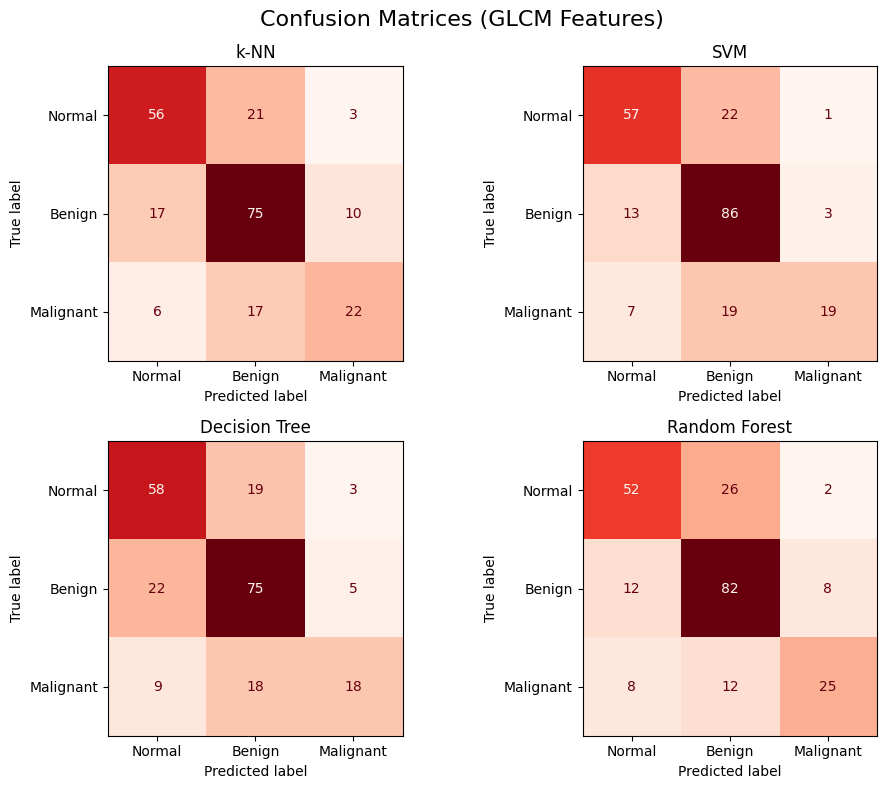

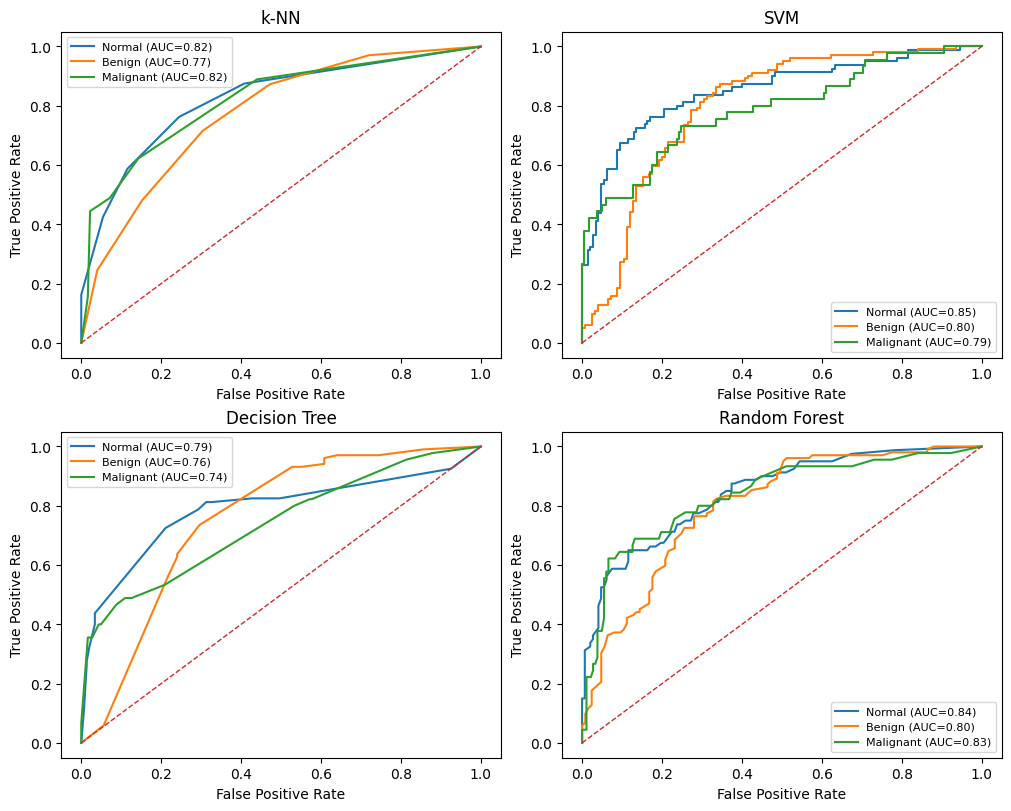

C:\Users\lucky\AppData\Local\Temp\ipykernel_18884\3714625098.py:60: UserWarning: The figure layout has changed to tight
  fig_roc.tight_layout()


In [6]:
results = []

fig_cm, axes_cm = plt.subplots(2, 2, figsize=(10, 8))
axes_cm = axes_cm.ravel()

fig_roc, axes_roc = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axes_roc = axes_roc.ravel()

for i, (name, model) in enumerate(models.items()):

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="macro", zero_division=0)
    rec = recall_score(y_test, preds, average="macro", zero_division=0)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)

    results.append([name, acc, prec, rec, f1])

    #print(f"\n{name}")
    #print(classification_report(y_test, preds, target_names=LABEL_NAMES, zero_division=0))

    # Confusion Matrix

    cm = confusion_matrix(y_test, preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
    disp.plot(ax=axes_cm[i], cmap="Reds", colorbar=False)

    axes_cm[i].set_title(name)

    # ROC Curves

    ax = axes_roc[i]

    for c in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, c], probs[:, c])
        roc_auc = auc(fpr, tpr)

        ax.plot(
            fpr,
            tpr,
            label=f"{LABEL_NAMES[c]} (AUC={roc_auc:.2f})"
        )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)

fig_cm.suptitle("Confusion Matrices (GLCM Features)", fontsize=16)
fig_cm.tight_layout()
plt.show()

fig_roc.suptitle("ROC Curves (GLCM Features)", fontsize=16)
fig_roc.tight_layout()
plt.show()

In [7]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,k-NN,0.674009,0.667050,0.641394,0.650692
1,SVM,0.713656,0.747837,0.659286,0.678677
2,Decision Tree,0.665198,0.671212,0.620098,0.631456
3,Random Forest,0.700441,0.706614,0.669826,0.682650
